# CIGALE + MAF on 100,000 COSMOS2020 galaxies

The catalog, filters, noise convention, MAF context, and summary plots match the FSPS
tutorial. CompoSED evaluates the delayed-tau SFH once and projects it onto CIGALE's
1 Myr grid; CIGALE then applies BC03, nebular emission, modified-starburst attenuation,
and redshifting/IGM attenuation.

BC03 metallicity is a two-value discrete prior. CompoSED learns its exact
categorical posterior and conditions the continuous MAF on the selected BC03
metallicity, so no continuous interpolation between template values occurs.


In [1]:
import os
# CIGALE v2022.0 imports deprecated pkg_resources internally. Keep its local
# installation path out of portable tutorial output, including spawned workers.
os.environ.setdefault("PYTHONWARNINGS", "ignore:pkg_resources is deprecated as an API:UserWarning")
import warnings
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")
import time
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import sys
import numpy as np

REPO_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "composed").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
DATA_PATH = REPO_ROOT / "notebooks/tutorials/data/cosmos2020_ugrizYJH_100k.npz"
if not DATA_PATH.exists():
    raise FileNotFoundError("Run 00_prepare_cosmos2020_ugrizYJH.ipynb first.")

with np.load(DATA_PATH, allow_pickle=False) as catalog:
    flux = catalog["flux_maggies"]
    sigma = catalog["sigma_maggies"]
    z_reference = catalog["lp_zbest"]
    mass_reference = catalog["lp_mass_med"]
    sfr_reference = catalog["lp_sfr_med"]
    dust_reference = catalog["lp_dust"]
    BAND_NAMES = tuple(catalog["band_names"].astype(str))
    FILTER_NAMES = tuple(catalog["sedpy_filter_names"].astype(str))
    SINGLE_OBJECT = int(catalog["single_object_position"])

print(f"Loaded {flux.shape[0]:,} galaxies in {flux.shape[1]} bands")
print("Single tutorial object:", SINGLE_OBJECT, "z_ref=", z_reference[SINGLE_OBJECT])

from sedpy.observate import load_filters
from composed.filters import FilterSet

filters = FilterSet(load_filters(list(FILTER_NAMES)), names=BAND_NAMES)


Loaded 100,000 galaxies in 8 bands
Single tutorial object: 36096 z_ref= 1.0001


## Model and priors


In [2]:
from composed import ConditionalCatalogNoise, DelayedTauSFH, Gaussian, Problem, SEDDataset, UniformPrior
from composed.backends.cigale import build_cigale_backend_and_parameter_space

sfh = DelayedTauSFH(age="age_fraction", age_kind="fraction_of_universe", tau="tau_gyr")
modules = ["bc03", "nebular", "dustatt_modified_starburst", "redshifting"]
module_parameters = {
    "bc03": {
        # Two values create a fitted ChoicePrior; one value declares a fixed choice.
        "metallicity": {"values": [0.008, 0.02]},
        "imf": {"values": [1], "dtype": "int"},
        "separation_age": 10,
    },
    "nebular": {
        "logU": -2.0, "zgas": 0.019, "ne": 100.0, "f_esc": 0.0,
        "f_dust": 0.0, "lines_width": 300.0, "emission": True,
    },
    "dustatt_modified_starburst": {
        "E_BV_lines": {"range": [0.0, 0.8]}, "E_BV_factor": 0.44,
        "uv_bump_wavelength": 217.5, "uv_bump_width": 35.0,
        "uv_bump_amplitude": 0.0, "powerlaw_slope": 0.0,
        "Ext_law_emission_lines": 1, "Rv": 3.1, "filters": "B_B90 & V_B90",
    },
    "redshifting": {"redshift": {"range": [0.05, 5.0]}},
}
backend, parameters = build_cigale_backend_and_parameter_space(
    modules,
    module_parameters,
    additional_priors={
        "log10_mass": UniformPrior(6.0, 13.0),
        "age_fraction": UniformPrior(0.30, 0.95),
        "tau_gyr": UniformPrior(0.1, 8.0),
    },
    sfh=sfh,
    photometry_mode="sedpy",
    default_z_key="redshift",
)
MODEL_DISCREPANCY = 0.05
QUICK = os.environ.get("COMPOSED_TUTORIAL_QUICK", "0") == "1"
noise_checkpoint = REPO_ROOT / "outputs" / (
    "tutorial_cosmos2020_survey_noise_quick" if QUICK
    else "tutorial_cosmos2020_survey_noise"
)

if (noise_checkpoint / "manifest.json").exists():
    survey_noise = ConditionalCatalogNoise.load(noise_checkpoint, device="cpu")
    print("Loaded shared COSMOS2020 survey-noise model")
else:
    catalog_magnitude = np.full_like(flux, np.nan)
    positive_flux = np.isfinite(flux) & (flux > 0.0)
    catalog_magnitude[positive_flux] = -2.5 * np.log10(flux[positive_flux])
    survey_noise = ConditionalCatalogNoise.fit(
        catalog_magnitude,
        sigma,
        band_names=BAND_NAMES,
        flux_unit="maggies",
        seed=40,
        hidden_features=64,
        num_transforms=4,
        num_blocks=2,
        epochs=3 if QUICK else 50,
        batch_size=1024,
        validation_split=0.1,
        patience=10,
        device="cpu",
        support_policy="warn",
        invalid_rows="filter",
        catalog_source=str(DATA_PATH),
        row_selection="prepared COSMOS2020 complete ugrizYJH rows",
    )
    survey_noise.save(noise_checkpoint)

# The noise flow is calibrated only on the complete-row COSMOS support.
# Prior draws outside that support are explicitly rejected and resampled.
survey_noise.support_policy = "raise"

data = SEDDataset(
    BAND_NAMES,
    flux[SINGLE_OBJECT],
    sigma[SINGLE_OBJECT],
    flux_unit="maggies",
)
problem = Problem(
    backend,
    parameters,
    data,
    Gaussian(photometric_model_discrepancy=MODEL_DISCREPANCY),
    filters=filters,
)

print("Problem parameter order:", parameters.names)
print("Discrete BC03 metallicities:", parameters.priors["metallicity"].values)
print("Fixed BC03 IMF code:", module_parameters["bc03"]["imf"]["values"][0])


Loaded shared COSMOS2020 survey-noise model
Problem parameter order: ('log10_mass', 'age_fraction', 'tau_gyr', 'metallicity', 'E_BV_lines', 'redshift')
Discrete BC03 metallicities: (0.008, 0.02)
Fixed BC03 IMF code: 1


### Survey noise versus model discrepancy

`sigma` is the raw COSMOS catalog uncertainty and is the uncertainty supplied
to the neural context at both training and inference. `survey_noise` learns the
joint multiband distribution
`q(log10 sigma_catalog | noiseless AB magnitudes)` from complete catalog rows.

The separate `MODEL_DISCREPANCY` enters only through the declared likelihood:

`sigma_draw^2 = sigma_catalog^2 + (MODEL_DISCREPANCY * f_model)^2`.

It is never estimated from `f_obs` and is never added to the SBI context.

In [3]:
from composed import (
    InferenceResult, MAF, PhotometricContext, SBITrainingSet, Simulate,
    TrainedMAFSBI, fit, problem_fingerprint, train_sbi,
)

QUICK = os.environ.get("COMPOSED_TUTORIAL_QUICK", "0") == "1"
N_TRAIN = 2_000 if QUICK else 300_000
N_TARGET = 512 if QUICK else flux.shape[0]
if QUICK and SINGLE_OBJECT >= N_TARGET:
    TARGET_INDICES = np.concatenate([np.arange(N_TARGET - 1), [SINGLE_OBJECT]])
else:
    TARGET_INDICES = np.arange(N_TARGET)
SINGLE_SUMMARY_POSITION = int(np.flatnonzero(TARGET_INDICES == SINGLE_OBJECT)[0])
N_POSTERIOR = 32 if QUICK else 128
N_SINGLE_DRAWS = 512 if QUICK else 30_000
EPOCHS = 10 if QUICK else 500
N_WORKERS = min(8, os.cpu_count() or 1)
OUTPUT = REPO_ROOT / "outputs/tutorial_cigale_maf_cosmos2020"
CHECKPOINT = OUTPUT / "maf"
TRAINING_CACHE = OUTPUT / "training_simulations.npz"
FORCE = os.environ.get("COMPOSED_TUTORIAL_FORCE", "0") == "1"
OUTPUT.mkdir(parents=True, exist_ok=True)

simulation = Simulate(
    n=N_TRAIN, noise_model=survey_noise, infer=parameters.names,
    context=PhotometricContext("snr_logsigma", flux_unit="maggies"),
    n_workers=N_WORKERS, batch_size=128, executor="process", mp_context="spawn",
    failure_policy="resample", warn_retry_fraction=0.05,
)

posterior = None
if (CHECKPOINT / "manifest.json").exists() and not FORCE:
    try:
        candidate = TrainedMAFSBI.load(CHECKPOINT, device="auto")
        saved_problem = candidate.metadata["training_set_metadata"]["problem"]
        if problem_fingerprint(saved_problem) != problem_fingerprint(problem):
            raise ValueError("checkpoint was trained for a different Problem")
        if candidate.theta_names != parameters.names:
            raise ValueError("checkpoint has a different inferred-parameter target")
        posterior = candidate
        print(f"Loaded matching MAF checkpoint: {CHECKPOINT.relative_to(REPO_ROOT)}")
    except (FileNotFoundError, KeyError, RuntimeError, TypeError, ValueError) as error:
        print(f"Ignoring stale MAF checkpoint: {error}")

t0 = time.perf_counter()
if posterior is None:
    maf_method = MAF(
        hidden_features=256, num_transforms=6, num_blocks=3, epochs=EPOCHS,
        batch_size=2048, validation_split=0.1, patience=None, device="auto",
        num_samples=N_SINGLE_DRAWS, inference_batch_size=8192,
    )
    training = None
    if TRAINING_CACHE.exists():
        with np.load(TRAINING_CACHE, allow_pickle=False) as cached:
            if str(cached["problem_fingerprint"]) == problem_fingerprint(problem):
                training = SBITrainingSet.from_photometry(
                    cached["theta"], cached["flux"], cached["sigma"],
                    theta_names=parameters.names, band_names=BAND_NAMES,
                    source="cached composed.problem.simulate",
                    context=PhotometricContext("snr_logsigma", flux_unit="maggies"),
                    flux_unit="maggies", parameter_space=parameters,
                    metadata={"problem": problem.specification()},
                )
            else:
                print("Ignoring stale training simulations for a different Problem")
    if training is not None:
        posterior = train_sbi(training, maf_method, seed=52)
        single_draws = posterior.sample(
            data, num_samples=N_SINGLE_DRAWS, batch_size=8192, seed=52,
        )[0]
        maf_single = InferenceResult(
            samples=single_draws, logp=None, weights=np.ones(N_SINGLE_DRAWS),
            parameter_names=posterior.theta_names, sampler_name="maf",
            metadata={"problem": problem.specification(), "reused_training_cache": True},
            inference_state=posterior,
        )
        print(f"Retrained from cached simulations: {time.perf_counter() - t0:.1f} s")
    else:
        # First execution: simulate, train, and retain the expensive simulation table.
        maf_single = fit(problem, maf_method, training=simulation, seed=52)
        posterior = maf_single.inference_state
        np.savez_compressed(
            TRAINING_CACHE,
            theta=posterior.training_set.theta,
            flux=posterior.training_set.x_native,
            sigma=posterior.training_set.sigma_native,
            problem_fingerprint=problem_fingerprint(problem),
        )
        print(f"End-to-end SBI fit: {time.perf_counter() - t0:.1f} s")
    posterior.save(CHECKPOINT, overwrite=True)
else:
    single_draws = posterior.sample(
        data, num_samples=N_SINGLE_DRAWS, batch_size=8192, seed=52,
    )[0]
    maf_single = InferenceResult(
        samples=single_draws,
        logp=None,
        weights=np.ones(N_SINGLE_DRAWS),
        parameter_names=posterior.theta_names,
        sampler_name="maf",
        metadata={"problem": problem.specification(), "loaded_checkpoint": str(CHECKPOINT)},
        inference_state=posterior,
    )
    print(f"Checkpoint load and single-object sampling: {time.perf_counter() - t0:.1f} s")
print("MAF device:", posterior.estimator.device)
print("MAF target parameters:", posterior.theta_names)


Ignoring stale MAF checkpoint: checkpoint was trained for a different Problem
Ignoring stale training simulations for a different Problem


${REPO_ROOT}/composed/sbi.py:2881: SBISimulationFailureWarning: SBI simulator failure fraction is 31.2% after 128 attempts (88/300000 accepted so far). The effective training prior is being conditioned on simulator success. Most common failures: builtins.ValueError (40).
  theta_full, x_native, sigma_native, sim_metadata = simulate_training_set(


${REPO_ROOT}/composed/sbi.py:2881: SBISimulationFailureWarning: Replaced 132558 failed simulation(s). Returned theta rows are draws from the declared prior conditioned on simulator success; inspect metadata['failures'] before training.
  theta_full, x_native, sigma_native, sim_metadata = simulate_training_set(


End-to-end SBI fit: 3881.2 s
MAF device: mps
MAF target parameters: ('log10_mass', 'age_fraction', 'tau_gyr', 'metallicity', 'E_BV_lines', 'redshift')


## Batched catalog inference


In [4]:
t0 = time.perf_counter()
summary = posterior.summarize_catalog(
    flux[TARGET_INDICES], sigma=sigma[TARGET_INDICES], input_units="native",
    num_samples=N_POSTERIOR, batch_size=8192, seed=53,
)
inference_seconds = time.perf_counter() - t0
summary.save(OUTPUT / "catalog_summary.npz")
print(f"{N_TARGET:,} galaxies x {N_POSTERIOR} draws in {inference_seconds:.2f} s")
print(f"{N_TARGET * N_POSTERIOR / inference_seconds:,.0f} posterior draws/s")


${TMPDIR}/ipykernel_72499/1384780385.py:2: SBIContextSupportWarning: 2074/100000 observation(s) lie outside the coordinate-wise SBI training range. Samples are extrapolations; inputs were not clipped. snr:u: observed [-30.371, -4.1201], training [-4.1144, 1.3956e+05]; snr:g: observed [-31.454, -4.1907], training [-4.1895, 37152]; snr:r: observed [-10.435, -4.0327], training [-3.6099, 34937]; snr:i: observed [-11.973, -4.6314], training [-3.1883, 52254]; snr:z: observed [-8.7507, -5.5205], training [-3.811, 35338]; snr:Y: observed [-15.271, -3.9469], training [-3.794, 16455]; 6 additional feature(s)
  summary = posterior.summarize_catalog(


${TMPDIR}/ipykernel_72499/1384780385.py:2: SBIPosteriorSaturationWarning: A bounded SBI marginal is both narrow (16-84% width <= 1% of the prior coordinate) and close to a prior edge (median within 5%). This can indicate posterior truncation, context extrapolation, or neural saturation. tau_gyr (lower edge): 13 object(s), indices [991, 7550, 9370, 15434, 18972, ...]; E_BV_lines (lower edge): 79 object(s), indices [1467, 1568, 3441, 3632, 8091, ...]; redshift (lower edge): 29 object(s), indices [1316, 5538, 9235, 12814, 15121, ...]; redshift (upper edge): 6 object(s), indices [48588, 49425, 52260, 82000, 89005, ...]; age_fraction (lower edge): 1 object(s), indices [85827]; E_BV_lines (upper edge): 1 object(s), indices [95240]
  summary = posterior.summarize_catalog(


100,000 galaxies x 128 draws in 84.52 s
151,446 posterior draws/s


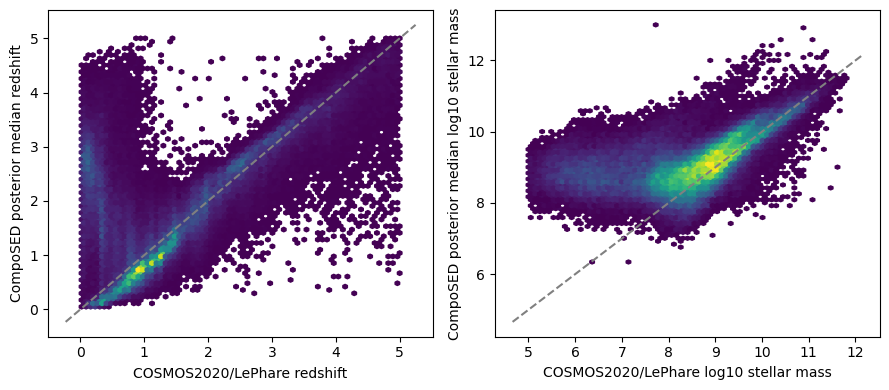

In [5]:
z_index = posterior.theta_names.index("redshift")
mass_index = posterior.theta_names.index("log10_mass")
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].hexbin(z_reference[TARGET_INDICES], summary.median[:, z_index], gridsize=70, mincnt=1)
axes[1].hexbin(mass_reference[TARGET_INDICES], summary.median[:, mass_index], gridsize=70, mincnt=1)
for ax, name in zip(axes, ("redshift", "log10 stellar mass")):
    lo, hi = ax.get_xlim(); ax.plot([lo, hi], [lo, hi], "--", color="0.5")
    ax.set(xlabel=f"COSMOS2020/LePhare {name}", ylabel=f"CompoSED posterior median {name}")
fig.tight_layout()


## MAF posterior for the single-galaxy comparison

This is the same COSMOS2020 galaxy and the same CIGALE model fitted with TAMIS in
`03_cigale_tamis_single_galaxy.ipynb`. We retain 30,000 raw MAF draws here so the
learned posterior geometry can be inspected directly.


MAF posterior medians: {'log10_mass': 10.044387183744181, 'age_fraction': 0.6912088355934766, 'tau_gyr': 2.6084619450298803, 'metallicity': 0.008, 'E_BV_lines': 0.6886129476120634, 'redshift': 0.8979191124001717}
MAF exact P(BC03 metallicity | photometry): {0.008: 0.8442888, 0.02: 0.15571119}
LePhare comparison: z= 1.0001 logM= 10.00341


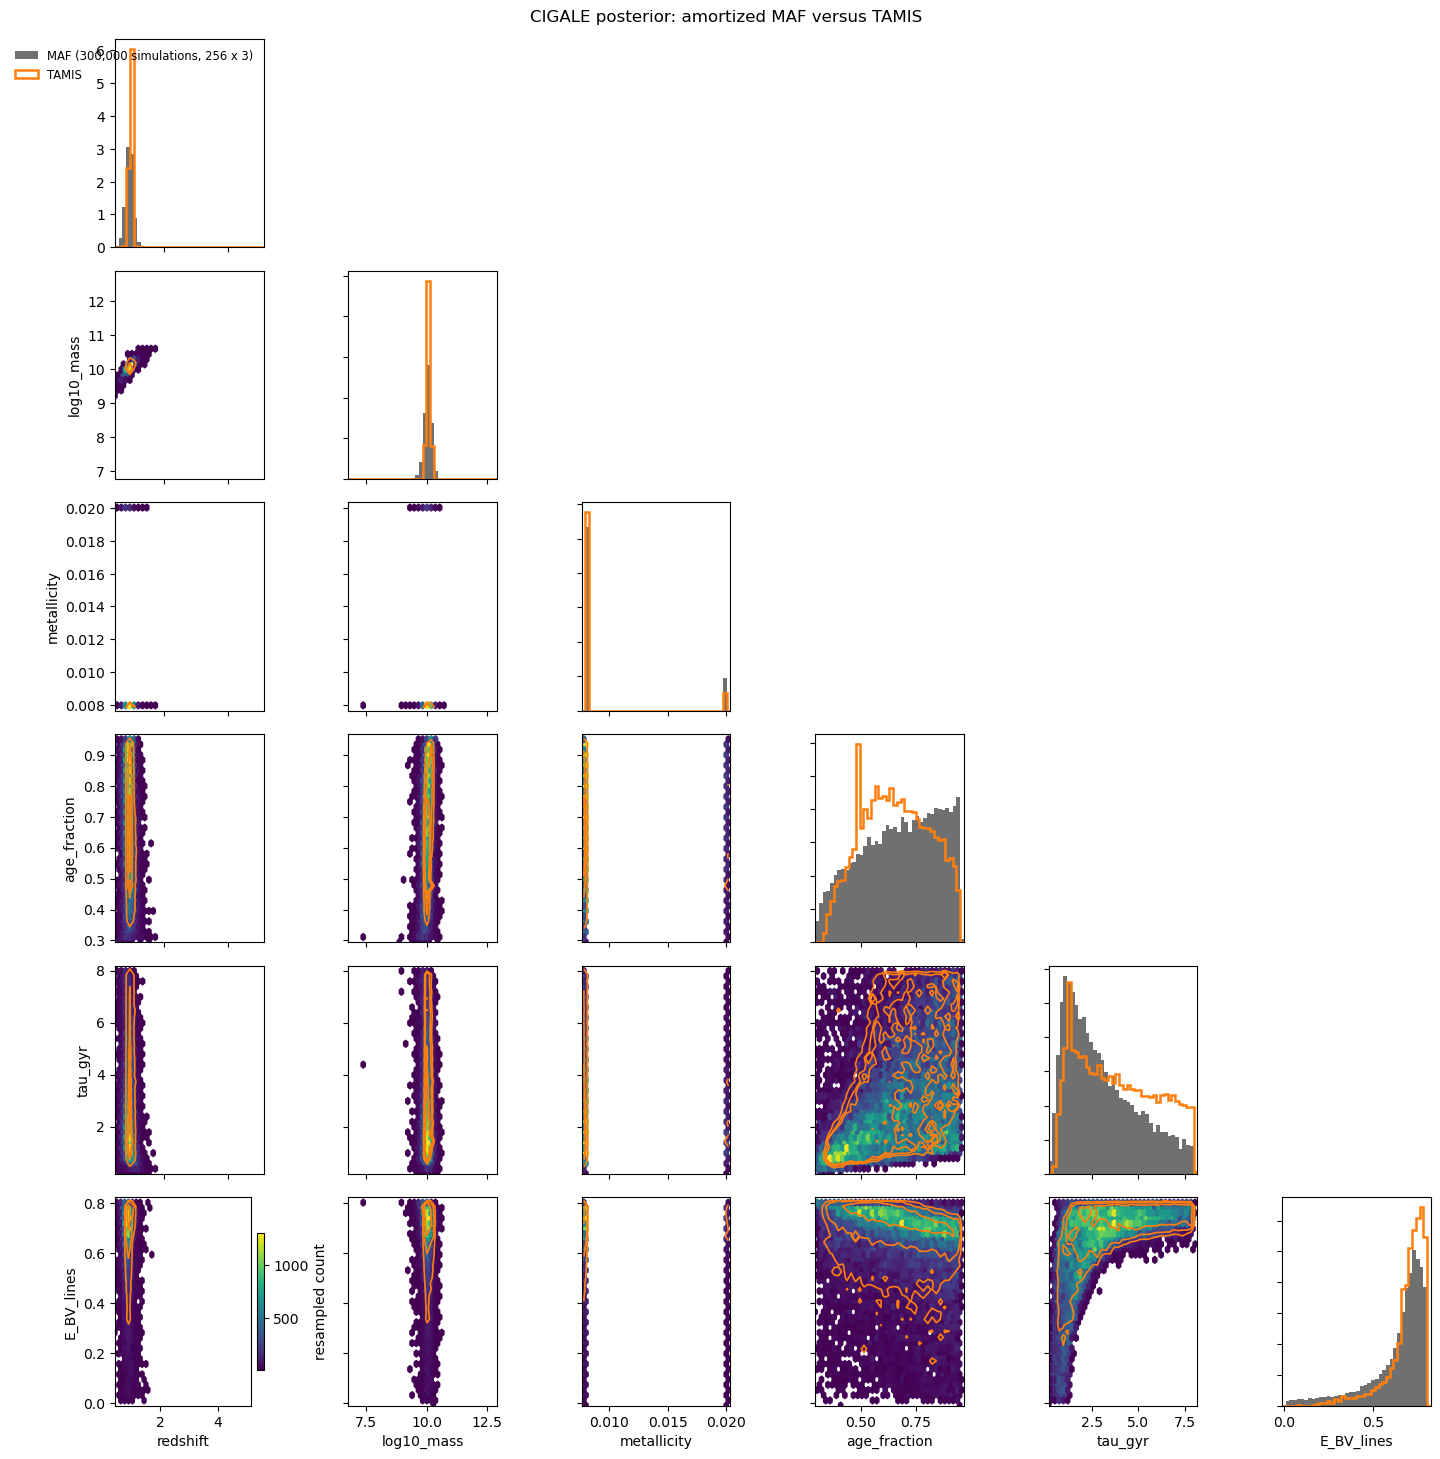

In [6]:
from composed import load_inference_result, require_result_matches_problem
from composed.plot import plot_corner_hexbin

reference_path = REPO_ROOT / "outputs/tutorial_cigale_tamis_single"
reference_mc = None
if reference_path.exists():
    try:
        reference_mc = require_result_matches_problem(
            load_inference_result(reference_path), problem
        )
    except ValueError as error:
        print(f"Ignoring TAMIS result for a different Problem: {error}")
if reference_mc is None:
    print("Run 03_cigale_tamis_single_galaxy.ipynb to add the TAMIS contours.")

corner_parameters = [
    "redshift", "log10_mass", "metallicity", "age_fraction", "tau_gyr", "E_BV_lines",
]
fig, _ = plot_corner_hexbin(
    maf_single,
    parameters=corner_parameters,
    comparison_result=reference_mc,
    result_label=f"MAF ({N_TRAIN:,} simulations, 256 x 3)",
    comparison_label="TAMIS",
    max_points=N_SINGLE_DRAWS,
    seed=55,
)
fig.suptitle("CIGALE posterior: amortized MAF versus TAMIS", y=1.01)
fig.savefig(OUTPUT / "single_object_maf_vs_tamis_corner.png", dpi=160, bbox_inches="tight")
print("MAF posterior medians:", dict(zip(posterior.theta_names, maf_single.posterior_median)))
metallicity_posterior = posterior.discrete_probabilities(data)["marginals"]["metallicity"]
metallicity_probability = dict(zip(
    metallicity_posterior["support"], metallicity_posterior["probability"][0]
))
print("MAF exact P(BC03 metallicity | photometry):", metallicity_probability)
print("LePhare comparison: z=", z_reference[SINGLE_OBJECT], "logM=", mass_reference[SINGLE_OBJECT])


posterior-median log10 SFR: 0.6606814192269587
LePhare reference log10 SFR: 1.09896


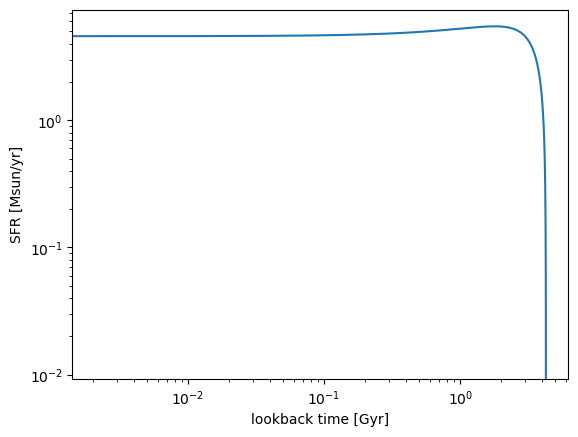

In [7]:
from composed import derive_sfh_quantities

median_params = dict(zip(posterior.theta_names, summary.median[SINGLE_SUMMARY_POSITION]))
derived = derive_sfh_quantities(backend, median_params, filters)
lookback = derived.time_gyr[-1] - derived.time_gyr
plt.plot(lookback[::-1], derived.sfr_msun_per_yr[::-1])
plt.xscale("log"); plt.yscale("log")
plt.xlabel("lookback time [Gyr]"); plt.ylabel("SFR [Msun/yr]")
print("posterior-median log10 SFR:", derived.log10_sfr)
print("LePhare reference log10 SFR:", sfr_reference[SINGLE_OBJECT])
